In [9]:
from lib.contact_settings import *
from lib.contact_wheel_rail import wheel, rail
from lib.contact_dyn_state import dynamic_state
from lib.contact_solver import patch_search
from lib.contact_material import material
from lib.contact_methods import eqv_el_normal_contact
import matplotlib.pyplot as plt

In [10]:
Wheel_1 = wheel(lr=LEFT)
Wheel_2 = wheel()
Rai_1 = rail(lr=LEFT)
Rai_2 = rail()

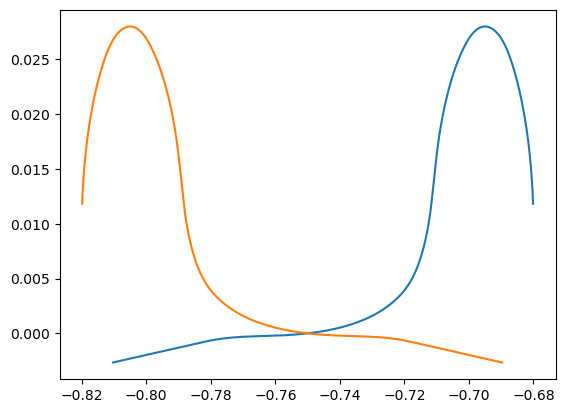

In [11]:
fig, ax = plt.subplots()
ax.plot(Wheel_1.wheel_start_pos[:,0], Wheel_1.wheel_start_pos[:,1])
ax.plot(Wheel_2.wheel_start_pos[:,0]-0.75*2, Wheel_2.wheel_start_pos[:,1])

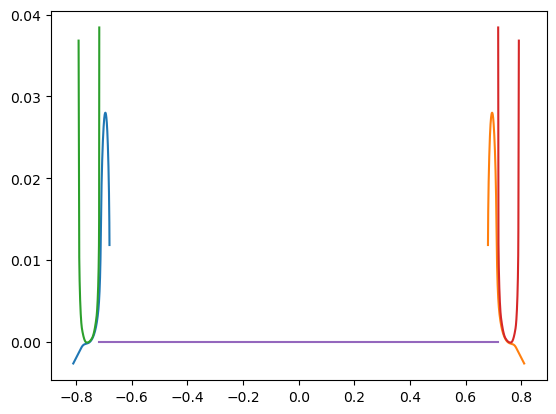

In [12]:
fig, ax = plt.subplots()
ax.plot(Wheel_1.wheel_start_pos[:,0], Wheel_1.wheel_start_pos[:,1])
ax.plot(Wheel_2.wheel_start_pos[:,0], Wheel_2.wheel_start_pos[:,1])
ax.plot(Rai_1.rail_start_pos[:,0], Rai_1.rail_start_pos[:,1])
ax.plot(Rai_2.rail_start_pos[:,0], Rai_2.rail_start_pos[:,1])
ax.plot([-Rai_1.gauge/2, Rai_1.gauge/2],[0,0])

In [13]:
# new_state = dynamic_state(state_yaw=3*np.pi/180)
# new_state = dynamic_state(state_y=0, state_yaw=3*np.pi/180)
new_state = dynamic_state()

print(new_state.state_y)

0


In [14]:
Wheel_dyn_0 = wheel(lr=RIGHT)
Wheel_dyn_1 = wheel(lr=LEFT)

# Need check thge left wheel because it gives wierd results

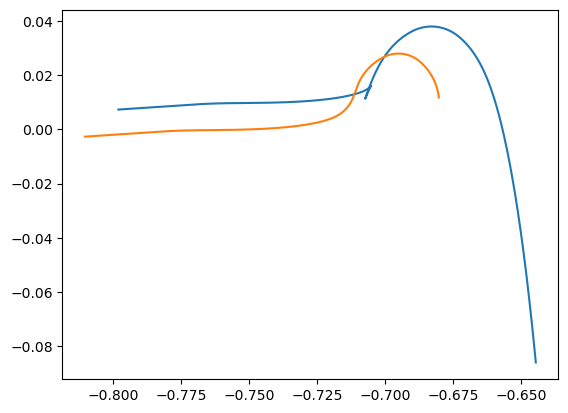

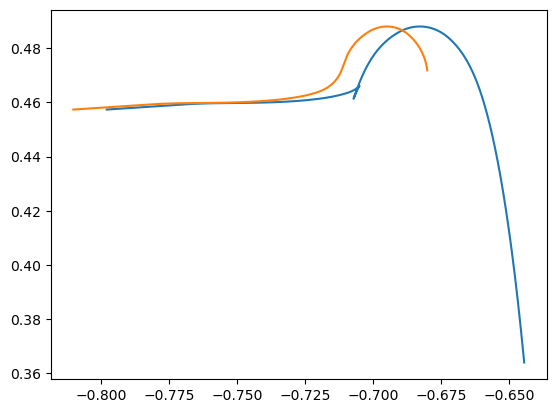

In [15]:
# new_state = dynamic_state(state_y=0, state_yaw=0)
new_state.state_yaw = 1.5*3*np.pi/180
new_state.state_y = 0.01
new_state.state_z = 0.01
Wheel_dyn_1.set_dynamic_state(new_state)
Wheel_dyn_1.calculate_position()

fig, ax = plt.subplots()
ax.plot(Wheel_dyn_1.wheel_profile_pos[:,0], Wheel_dyn_1.wheel_profile_pos[:,1])
ax.plot(Wheel_dyn_1.wheel_start_pos[:,0], Wheel_dyn_1.wheel_start_pos[:,1])

fig, ax = plt.subplots()
ax.plot(Wheel_dyn_1.wheel_radius[:,0], Wheel_dyn_1.wheel_radius[:,1])
# ax.plot(Wheel_dyn_1.wheel_profile_pos[:,0], Wheel_dyn_1.wheel_profile_pos[:,1])
ax.plot(Wheel_dyn_1.wheel_start_radius[:,0], Wheel_dyn_1.wheel_start_radius[:,1])

In [16]:
Wheel_1 = wheel(lr=LEFT)
Wheel_2 = wheel()
Rai_1 = rail(lr=LEFT)
Rai_2 = rail()

material_model = material()
contact_patches = [eqv_el_normal_contact(), eqv_el_normal_contact(), eqv_el_normal_contact()]

new_state = dynamic_state(state_z = 0.0001)
Wheel_1.set_dynamic_state(new_state)
Wheel_1.calculate_position()

patch_search(Wheel_1, Rai_1, material_model, contact_patches)

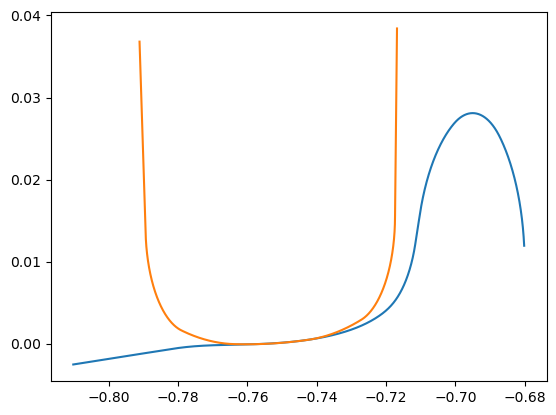

In [17]:
fig, ax = plt.subplots()
ax.plot(Wheel_1.wheel_profile_pos[:,0], Wheel_1.wheel_profile_pos[:,1])
ax.plot(Rai_1.rail_profile_pos[:,0], Rai_1.rail_profile_pos[:,1])

In [18]:
from calc_routines.determine_static_contact import static_contact

In [19]:
dy = 0.05e-3
deltays = np.arange(-20e-3, 20e-3 + dy, dy)

Wheel = wheel(lr=RIGHT)
Rail = rail(rail_inclination=30, lr=RIGHT)

material_model = material()
contact_patches = [eqv_el_normal_contact(), eqv_el_normal_contact(), eqv_el_normal_contact()]


In [20]:
stuff = static_contact(deltays, Wheel, Rail, contact_patches, material_model)

c:\Users\rocco\Desktop\PPP\prove\gitRepo\SimRail\calc_routines\determine_static_contact.py:76: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root = fsolve(
c:\Users\rocco\Desktop\PPP\prove\gitRepo\SimRail\calc_routines\determine_static_contact.py:76: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  root = fsolve(
c:\Users\rocco\Desktop\PPP\prove\gitRepo\SimRail\lib\contact_solver.py:22: RuntimeWarning: invalid value encountered in sqrt
  xl = np.sqrt(2 * Rlocal * Shape)
c:\Users\rocco\Desktop\PPP\prove\gitRepo\SimRail\calc_routines\determine_static_contact.py:88: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root = fsolve(


In [21]:
print(len(stuff))
print(stuff["patch_0"])

3
[[ 4.01077740e-04  5.00212877e+04  5.00000000e+04 ...  7.22461297e-05
   6.05049940e-03  3.28643885e-03]
 [ 3.99623084e-04  5.00211588e+04  5.00000000e+04 ...  7.22533769e-05
   6.04941938e-03  3.28643827e-03]
 [ 3.98186087e-04  5.00210464e+04  5.00000000e+04 ...  7.22235445e-05
   6.04924092e-03  3.28975387e-03]
 ...
 [-2.00379678e-02  6.12890604e+04  5.00000001e+04 ...  1.08685663e-04
   8.40976720e-03  9.64080106e-04]
 [-2.00735100e-02  6.12119298e+04  5.00000000e+04 ...  1.08759773e-04
   8.39865228e-03  9.60708180e-04]
 [-2.01088422e-02  6.11242742e+04  5.00000000e+04 ...  1.08666224e-04
   8.39229207e-03  9.60607573e-04]]


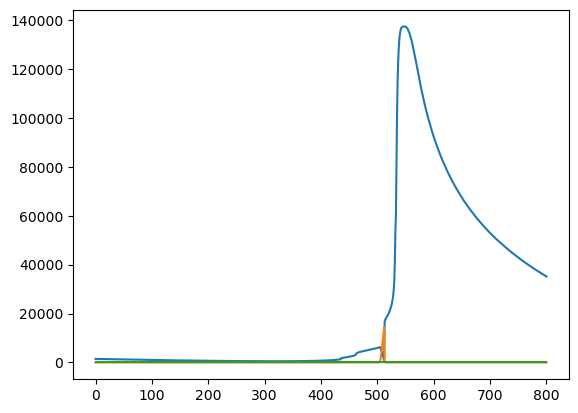

In [23]:
fig, ax = plt.subplots()
ax.plot(stuff["patch_0"][:,3])
ax.plot(stuff["patch_1"][:,3])
ax.plot(stuff["patch_2"][:,3])